Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5527872..1.6666666].


torch.Size([3, 224, 224])
['antelope', 'buffalo', 'chimpanzee', 'cow', 'deer', 'dolphin', 'elephant', 'fox', 'giant+panda', 'giraffe', 'gorilla', 'grizzly+bear', 'hamster', 'hippopotamus', 'horse', 'humpback+whale', 'leopard', 'lion', 'moose', 'otter', 'ox', 'pig', 'polar+bear', 'rabbit', 'rhinoceros', 'seal', 'sheep', 'squirrel', 'tiger', 'zebra']


(-0.5, 223.5, 223.5, -0.5)

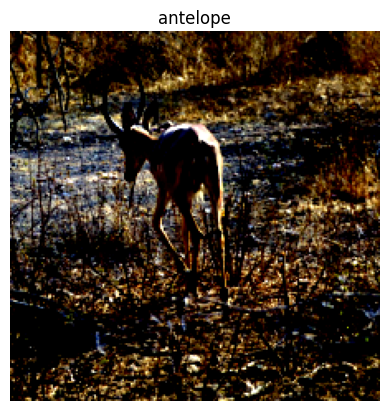

In [ ]:
#create transforms
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize(300),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Changed to match train size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# data
from torchvision.datasets import ImageFolder
from pathlib import Path 

folder = Path("data/Animals_with_Attributes2")
train_data = ImageFolder(root= folder / "train",
                        transform= train_transforms,
                        target_transform=None)
test_data = ImageFolder(root=folder / "test",
                        transform = test_transforms,
                        target_transform=None)


# visualizing data
import matplotlib.pyplot as plt
img, label = train_data[3]
print(img.shape)
print(train_data.classes)
plt.imshow(img.permute(1,2,0))
plt.title(f"{train_data.classes[label]}")
plt.axis(False)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.1171243].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..1.7511113].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3815396..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].


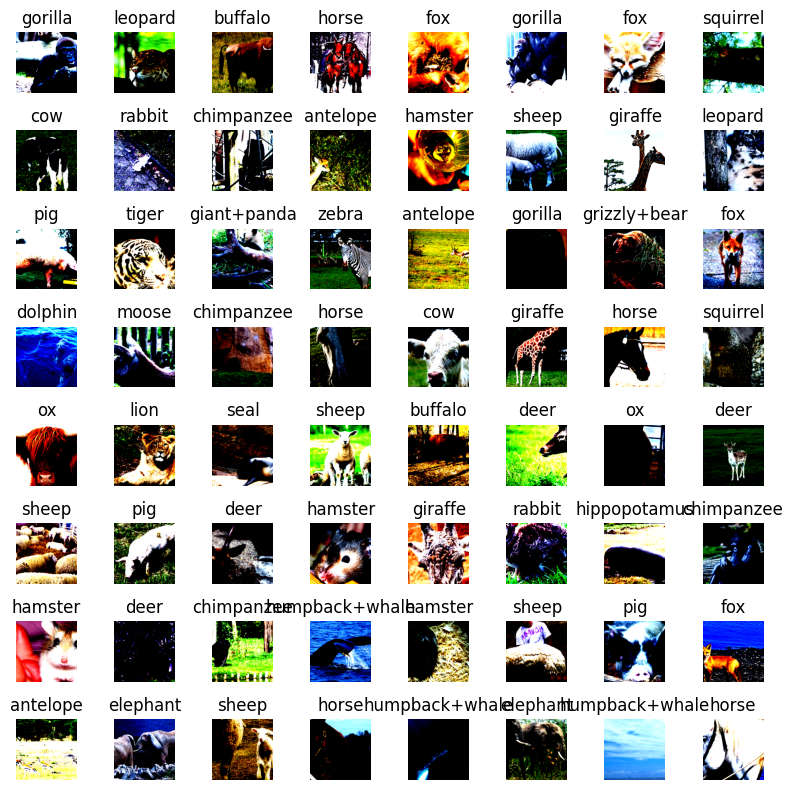

In [2]:
# data loader 
from torch.utils.data import DataLoader
from helper_functions import show_batch
batch = 64
train_loader = DataLoader(train_data, batch, shuffle=True, num_workers=0, drop_last= True)
test_loader = DataLoader(test_data, batch, shuffle=False, num_workers=0, drop_last=True)

# vizualize loader batch
show_batch(train_loader, train_data.classes, figsize=(8,8))

## Recreating MobileNetV3
* https://paperswithcode.com/method/mobilenetv3
* https://arxiv.org/pdf/1905.02244v5

In [3]:
'''MobileNetV3 in PyTorch.

See the paper "Inverted Residuals and Linear Bottlenecks:
Mobile Networks for Classification, Detection and Segmentation" for more details.
'''
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import init


class hswish(nn.Module):
    def forward(self, x):
        out = x * F.relu6(x + 3, inplace=True) / 6
        return out


class hsigmoid(nn.Module):
    def forward(self, x):
        out = F.relu6(x + 3, inplace=True) / 6
        return out


class SeModule(nn.Module):
    def __init__(self, in_size, reduction=4):
        super(SeModule, self).__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_size, in_size // reduction, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(in_size // reduction),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_size // reduction, in_size, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(in_size),
            hsigmoid()
        )

    def forward(self, x):
        return x * self.se(x)


class Block(nn.Module):
    '''expand + depthwise + pointwise'''
    def __init__(self, kernel_size, in_size, expand_size, out_size, nolinear, semodule, stride):
        super(Block, self).__init__()
        self.stride = stride
        self.se = semodule

        self.conv1 = nn.Conv2d(in_size, expand_size, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(expand_size)
        self.nolinear1 = nolinear
        self.conv2 = nn.Conv2d(expand_size, expand_size, kernel_size=kernel_size, stride=stride, padding=kernel_size//2, groups=expand_size, bias=False)
        self.bn2 = nn.BatchNorm2d(expand_size)
        self.nolinear2 = nolinear
        self.conv3 = nn.Conv2d(expand_size, out_size, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn3 = nn.BatchNorm2d(out_size)

        self.shortcut = nn.Sequential()
        if stride == 1 and in_size != out_size:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_size, out_size, kernel_size=1, stride=1, padding=0, bias=False),
                nn.BatchNorm2d(out_size),
            )

    def forward(self, x):
        out = self.nolinear1(self.bn1(self.conv1(x)))
        out = self.nolinear2(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.se != None:
            out = self.se(out)
        out = out + self.shortcut(x) if self.stride==1 else out
        return out

class MobileNetV3_Small(nn.Module):
    def __init__(self, num_classes= len(test_data.classes)):
        super(MobileNetV3_Small, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.hs1 = hswish()

        self.bneck = nn.Sequential(
            Block(3, 16, 16, 16, nn.ReLU(inplace=True), SeModule(16), 2),
            Block(3, 16, 72, 24, nn.ReLU(inplace=True), None, 2),
            Block(3, 24, 88, 24, nn.ReLU(inplace=True), None, 1),
            Block(5, 24, 96, 40, hswish(), SeModule(40), 2),
            Block(5, 40, 240, 40, hswish(), SeModule(40), 1),
            Block(5, 40, 240, 40, hswish(), SeModule(40), 1),
            Block(5, 40, 120, 48, hswish(), SeModule(48), 1),
            Block(5, 48, 144, 48, hswish(), SeModule(48), 1),
            Block(5, 48, 288, 96, hswish(), SeModule(96), 2),
            Block(5, 96, 576, 96, hswish(), SeModule(96), 1),
            Block(5, 96, 576, 96, hswish(), SeModule(96), 1),
        )


        self.conv2 = nn.Conv2d(96, 576, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(576)
        self.hs2 = hswish()
        self.linear3 = nn.Linear(576, 1280)
        self.bn3 = nn.BatchNorm1d(1280)
        self.hs3 = hswish()
        self.linear4 = nn.Linear(1280, num_classes)
        self.init_params()

    def init_params(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                init.normal_(m.weight, std=0.001)
                if m.bias is not None:
                    init.constant_(m.bias, 0)

    def forward(self, x):
        out = self.hs1(self.bn1(self.conv1(x)))
        out = self.bneck(out)
        out = self.hs2(self.bn2(self.conv2(out)))
        out = F.avg_pool2d(out, 7)
        out = out.view(out.size(0), -1)
        out = self.hs3(self.bn3(self.linear3(out)))
        out = self.linear4(out)
        return out


In [4]:
#setting up device 
user_device = "cuda" if torch.cuda.is_available() else "cpu"
print(user_device)

# create classweights for crossentropy loss since data is a bit imbalanced
classweights = torch.tensor([(850/1046), (850/895), (850/728), (850/1338), (850/1344), (850/946), (850/1038), (850/664), (850/874), (850/1202),
                             (850/872), (850/852), (850/779), (850/684), (850/1645), (850/709), (850/720), (850/1019), (850/704), (850/758), (850/728), (850/713),
                             (850/868), (850/1088), (850/696), (850/988), (850/1420), (850/1200), (850/877), (850/1170)])
classweights = classweights.to(device=user_device)
for index in range(len(train_data.classes)):
    print(f"The class: {train_data.classes[index]} || has weight: {classweights[index]}")    

cuda
The class: antelope || has weight: 0.8126195073127747
The class: buffalo || has weight: 0.9497206807136536
The class: chimpanzee || has weight: 1.167582392692566
The class: cow || has weight: 0.6352765560150146
The class: deer || has weight: 0.632440447807312
The class: dolphin || has weight: 0.8985201120376587
The class: elephant || has weight: 0.8188824653625488
The class: fox || has weight: 1.2801204919815063
The class: giant+panda || has weight: 0.972540020942688
The class: giraffe || has weight: 0.7071547508239746
The class: gorilla || has weight: 0.9747706651687622
The class: grizzly+bear || has weight: 0.9976525902748108
The class: hamster || has weight: 1.0911425352096558
The class: hippopotamus || has weight: 1.242690086364746
The class: horse || has weight: 0.5167173147201538
The class: humpback+whale || has weight: 1.1988716125488281
The class: leopard || has weight: 1.1805555820465088
The class: lion || has weight: 0.8341511487960815
The class: moose || has weight: 1.2

In [5]:
import torchmetrics

#create model and acc functions 
torch.manual_seed(42)
torch.cuda.manual_seed(42)
MobileNet_model_small = MobileNetV3_Small().to(user_device)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1, weight=classweights)      # smoothes label [0, 1, 0, 0] -> [0.1, 0.7, 0.1, 0.1] um generalisierung zu verbessern

acc_fn = torchmetrics.Accuracy(task= "multiclass", num_classes=len(test_data.classes)).to(user_device)

img, label = next(iter(train_loader))
print(f"batchsize {img.shape} || classcount: {len(test_data.classes)}")

#testing model output we expect float tensor with shape 8x5 (8 imgs and 5 classes per img)
MobileNet_model_small.eval()
with torch.inference_mode():
    logits = MobileNet_model_small(torch.rand(batch,3,244,244).to(user_device))
    print(logits.shape)


batchsize torch.Size([64, 3, 224, 224]) || classcount: 30
torch.Size([64, 30])


In [6]:
#Configure Optimizer
optimizer_1 = torch.optim.SGD(
    MobileNet_model_small.parameters(),
    lr=0.05,          # Placeholder; scheduler determines effective LR per batch
    momentum=0.85,
    nesterov=True,
    weight_decay=1e-4
)

epochs_1 = 100

scheduler_1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1,
    max_lr=0.2,            # Increased peak LR for better exploration
    pct_start=0.2,          # Warmup lasts 20% of the cycle
    div_factor=10,          # initial_lr ≈ 0.35 / 15 ≈ 0.0233
    final_div_factor=330,   # final_lr 
    steps_per_epoch=len(train_loader),
    epochs=epochs_1,             # Total training epochs (matching your intended schedule)
    anneal_strategy='linear',
    base_momentum=0.85,     # Starting momentum
    max_momentum=0.90       # Upper bound of momentum
)


In [7]:
import numpy as np

# training & testing loop
def train_step_CNN(MODEL: torch.nn.Module,
               LOADER: torch.utils.data.DataLoader,
               LOSSF: torch.nn.Module,
               ACCF: torchmetrics.Accuracy,
               OPTIM: torch.optim.Optimizer,
               SCHEDULER: None,
               DEVICE: torch.device):
    """Performs a CNN training step over a dataloader"""
    MODEL.train()
    train_loss, train_acc = 0, 0
    for image, label in LOADER:
        image, label = image.to(DEVICE), label.to(DEVICE)

        # MixUp - IMAGES ONLY
        #lam = np.random.uniform(0.025, 0.35)
        #index = torch.randperm(image.size(0))
        #mixed_images = lam * image + (1 - lam) * image[index]

        #training
        #logits = MODEL(mixed_images)
        logits = MODEL(image)

        # MixUp LABEL HANDLING
        #label_a = label
        #label_b = label[index]
        #mixed_labels = lam * label + (1 - lam) * label[index]

        #batch_loss = lam * loss_fn(logits, label_a) + (1 - lam) * loss_fn(logits, label_b)
        batch_loss = LOSSF(logits, label)
        train_loss += batch_loss
        #preds = torch.argmax(logits, dim=1)
        #is_correct = (preds == label_a) | (preds == label_b)  # Either original label
        #train_acc += is_correct.float().mean() * 100  # Percentage
        train_acc += ACCF(logits.argmax(dim=1), label)

        OPTIM.zero_grad()
        batch_loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(MODEL.parameters(), max_norm=1.0)
        
        OPTIM.step()

        if SCHEDULER != None:
            SCHEDULER.step()

    train_acc /= len(LOADER)*0.01
    train_loss /= len(LOADER)
    return train_loss, train_acc


def test_step_CNN(MODEL: torch.nn.Module,
                  LOADER: torch.utils.data.DataLoader,
                  LOSSF: torch.nn.Module,
                  ACCF: torchmetrics.Accuracy,
                  DEVICE: torch.device):
    """Performs a CNN testing step over a dataloader"""
    MODEL.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for image, label in LOADER:
            image, label = image.to(DEVICE) , label.to(DEVICE)
            logits = MODEL(image)
            batch_loss = LOSSF(logits, label)
            test_loss += batch_loss
            test_acc += ACCF(logits.argmax(dim=1), label)
        test_acc /= len(LOADER)*0.01
        test_loss /= len(LOADER)
        return test_loss, test_acc

from tqdm.auto import tqdm
def model_training_CNN(MODEL: torch.nn.Module,
               LOADER_TRAIN: torch.utils.data.DataLoader,
               LOADER_TEST: torch.utils.data.DataLoader,
               LOSSF: torch.nn.Module,
               ACCF: torchmetrics.Accuracy,
               OPTIM: torch.optim.Optimizer,
               DEVICE: torch.device,
               SCHEDULER: None,
               EPOCHS_TRAIN: int,
               Epochs_RETURN: int):
    """Combines "train_step_CNN" & "test_step_CNN" into one training function"""
    
    evaluation_dictionary = {"train_loss": [],
                             "train_acc": [], 
                             "test_loss": [],
                             "test_acc": [],
                             "epoch":[]}

    for epoch in tqdm(range(EPOCHS_TRAIN)):

        train_loss, train_acc = train_step_CNN(MODEL, LOADER_TRAIN, LOSSF, ACCF, OPTIM, SCHEDULER, DEVICE)    
        test_loss, test_acc = test_step_CNN(MODEL, LOADER_TEST, LOSSF, ACCF, DEVICE)    
        
        #append to eval_dict
        if epoch%Epochs_RETURN == 0:
            evaluation_dictionary["train_loss"].append(train_loss.cpu().detach().numpy())
            evaluation_dictionary["train_acc"].append(train_acc.cpu())
            evaluation_dictionary["test_loss"].append(test_loss.cpu())
            evaluation_dictionary["test_acc"].append(test_acc.cpu())
            evaluation_dictionary["epoch"].append(epoch)
            print(f"Epoch: {epoch} || train_loss: {train_loss:.4f} || train_acc: {train_acc:.4f} || test_loss: {test_loss:.4f} || test_acc: {test_acc:.4f}")

    return evaluation_dictionary

        

In [8]:
import numpy as np

eval_dict = model_training_CNN(MODEL=MobileNet_model_small,
                   LOADER_TRAIN= train_loader,
                   LOADER_TEST= test_loader,
                   LOSSF=loss_fn,
                   ACCF=acc_fn,
                   OPTIM= optimizer_1,
                   SCHEDULER= scheduler_1,
                   DEVICE= user_device, 
                   EPOCHS_TRAIN=epochs_1,
                   Epochs_RETURN=1)

  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\Admin\.conda\envs\gymenv\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch: 0 || train_loss: 3.0786 || train_acc: 14.5810 || test_loss: 3.1153 || test_acc: 18.5764
Epoch: 1 || train_loss: 2.6150 || train_acc: 30.3321 || test_loss: 2.9423 || test_acc: 21.7014
Epoch: 2 || train_loss: 2.3056 || train_acc: 41.1645 || test_loss: 2.9408 || test_acc: 27.9514
Epoch: 3 || train_loss: 2.0810 || train_acc: 49.0646 || test_loss: 2.4540 || test_acc: 39.4097
Epoch: 4 || train_loss: 1.9323 || train_acc: 54.5439 || test_loss: 2.4143 || test_acc: 42.7951
Epoch: 5 || train_loss: 1.8216 || train_acc: 58.5132 || test_loss: 2.1293 || test_acc: 48.0903
Epoch: 6 || train_loss: 1.7407 || train_acc: 62.0446 || test_loss: 2.1857 || test_acc: 46.9618
Epoch: 7 || train_loss: 1.6680 || train_acc: 64.4899 || test_loss: 2.2898 || test_acc: 47.3090
Epoch: 8 || train_loss: 1.6068 || train_acc: 66.9598 || test_loss: 2.0548 || test_acc: 51.8229
Epoch: 9 || train_loss: 1.5539 || train_acc: 68.6554 || test_loss: 2.0916 || test_acc: 50.0000
Epoch: 10 || train_loss: 1.5217 || train_acc: 70.0

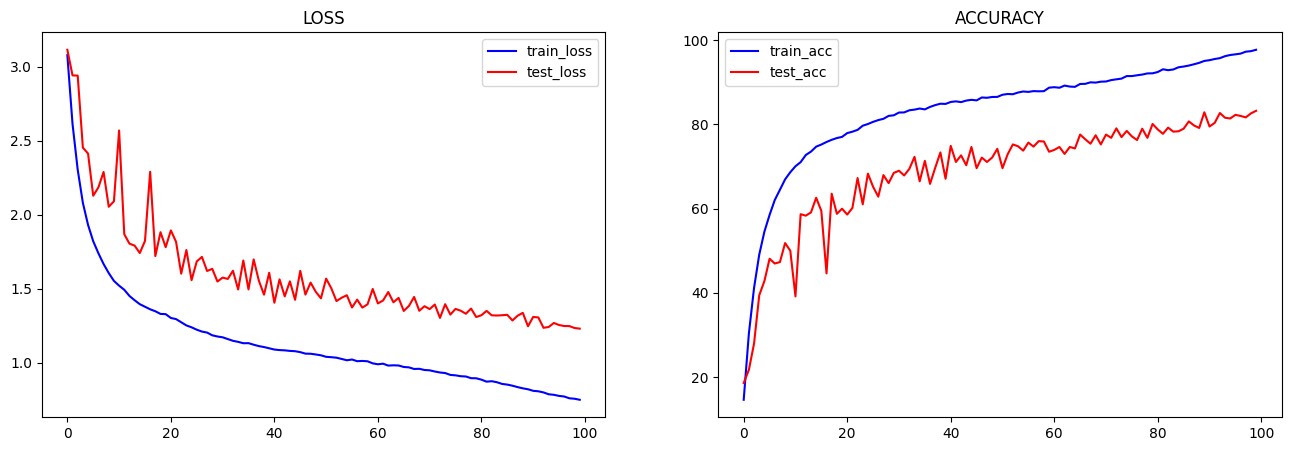

In [12]:
def plot_eval_dict(dict, fig_size= (14,5), start_epoch: int = 1, num_epochs: int=1000000):
    plt.figure(figsize= fig_size)
    plt.subplot(1,2,1)
    plt.plot(dict["epoch"][start_epoch:num_epochs], dict["train_loss"][start_epoch:num_epochs], color = "blue", label="train_loss")
    plt.plot(dict["epoch"][start_epoch:num_epochs], dict["test_loss"][start_epoch:num_epochs], color = "red", label="test_loss")
    plt.legend()
    plt.title("LOSS")

    plt.subplot(1,2,2)
    plt.plot(dict["epoch"][start_epoch:num_epochs], dict["train_acc"][start_epoch:num_epochs], color = "blue", label="train_acc")
    plt.plot(dict["epoch"][start_epoch:num_epochs], dict["test_acc"][start_epoch:num_epochs], color = "red", label="test_acc")
    plt.legend()
    plt.title("ACCURACY")

plot_eval_dict(eval_dict, fig_size=(16,5), start_epoch=0)

* 460 sec/item für batchsize 32
* 307 sec/item für batchsize 64

Epoch: 0 || train_loss: 3.0786 || train_acc: 14.5810 || test_loss: 3.1153 || test_acc: 18.5764
Epoch: 1 || train_loss: 2.6150 || train_acc: 30.3321 || test_loss: 2.9423 || test_acc: 21.7014
Epoch: 2 || train_loss: 2.3056 || train_acc: 41.1645 || test_loss: 2.9408 || test_acc: 27.9514
Epoch: 3 || train_loss: 2.0810 || train_acc: 49.0646 || test_loss: 2.4540 || test_acc: 39.4097
Epoch: 4 || train_loss: 1.9323 || train_acc: 54.5439 || test_loss: 2.4143 || test_acc: 42.7951
Epoch: 5 || train_loss: 1.8216 || train_acc: 58.5132 || test_loss: 2.1293 || test_acc: 48.0903
Epoch: 6 || train_loss: 1.7407 || train_acc: 62.0446 || test_loss: 2.1857 || test_acc: 46.9618
Epoch: 7 || train_loss: 1.6680 || train_acc: 64.4899 || test_loss: 2.2898 || test_acc: 47.3090
Epoch: 8 || train_loss: 1.6068 || train_acc: 66.9598 || test_loss: 2.0548 || test_acc: 51.8229
Epoch: 9 || train_loss: 1.5539 || train_acc: 68.6554 || test_loss: 2.0916 || test_acc: 50.0000
Epoch: 10 || train_loss: 1.5217 || train_acc: 70.0673 || test_loss: 2.5701 || test_acc: 39.1493
Epoch: 11 || train_loss: 1.4939 || train_acc: 71.0517 || test_loss: 1.8693 || test_acc: 58.6806
Epoch: 12 || train_loss: 1.4523 || train_acc: 72.7508 || test_loss: 1.8057 || test_acc: 58.3333
Epoch: 13 || train_loss: 1.4232 || train_acc: 73.5531 || test_loss: 1.7921 || test_acc: 59.1146
Epoch: 14 || train_loss: 1.3966 || train_acc: 74.7302 || test_loss: 1.7421 || test_acc: 62.5868
Epoch: 15 || train_loss: 1.3793 || train_acc: 75.2347 || test_loss: 1.8238 || test_acc: 59.4618
Epoch: 16 || train_loss: 1.3620 || train_acc: 75.8373 || test_loss: 2.2909 || test_acc: 44.6181
Epoch: 17 || train_loss: 1.3488 || train_acc: 76.3558 || test_loss: 1.7217 || test_acc: 63.5417
Epoch: 18 || train_loss: 1.3308 || train_acc: 76.7762 || test_loss: 1.8830 || test_acc: 58.7674
Epoch: 19 || train_loss: 1.3293 || train_acc: 77.0495 || test_loss: 1.7817 || test_acc: 59.9826
Epoch: 20 || train_loss: 1.3035 || train_acc: 77.9498 || test_loss: 1.8951 || test_acc: 58.5937
Epoch: 21 || train_loss: 1.2960 || train_acc: 78.2862 || test_loss: 1.8184 || test_acc: 60.1562
Epoch: 22 || train_loss: 1.2745 || train_acc: 78.7171 || test_loss: 1.6026 || test_acc: 67.2743
Epoch: 23 || train_loss: 1.2531 || train_acc: 79.7085 || test_loss: 1.7626 || test_acc: 61.0243
Epoch: 24 || train_loss: 1.2404 || train_acc: 80.1114 || test_loss: 1.5590 || test_acc: 68.3160
Epoch: 25 || train_loss: 1.2242 || train_acc: 80.6229 || test_loss: 1.6852 || test_acc: 65.1910
Epoch: 26 || train_loss: 1.2117 || train_acc: 81.0433 || test_loss: 1.7159 || test_acc: 62.8472
Epoch: 27 || train_loss: 1.2048 || train_acc: 81.3481 || test_loss: 1.6209 || test_acc: 67.9688
Epoch: 28 || train_loss: 1.1862 || train_acc: 82.0418 || test_loss: 1.6355 || test_acc: 66.0590
Epoch: 29 || train_loss: 1.1783 || train_acc: 82.1819 || test_loss: 1.5496 || test_acc: 68.4896
Epoch: 30 || train_loss: 1.1729 || train_acc: 82.8370 || test_loss: 1.5763 || test_acc: 69.0104
Epoch: 31 || train_loss: 1.1609 || train_acc: 82.8651 || test_loss: 1.5672 || test_acc: 67.8819
Epoch: 32 || train_loss: 1.1491 || train_acc: 83.3730 || test_loss: 1.6225 || test_acc: 69.4444
Epoch: 33 || train_loss: 1.1420 || train_acc: 83.5307 || test_loss: 1.4961 || test_acc: 72.3090
Epoch: 34 || train_loss: 1.1328 || train_acc: 83.7899 || test_loss: 1.6919 || test_acc: 66.4930
Epoch: 35 || train_loss: 1.1334 || train_acc: 83.5867 || test_loss: 1.4965 || test_acc: 71.3542
Epoch: 36 || train_loss: 1.1227 || train_acc: 84.1753 || test_loss: 1.6990 || test_acc: 65.8854
Epoch: 37 || train_loss: 1.1134 || train_acc: 84.6027 || test_loss: 1.5556 || test_acc: 69.7049
Epoch: 38 || train_loss: 1.1070 || train_acc: 84.9320 || test_loss: 1.4608 || test_acc: 73.3507
Epoch: 39 || train_loss: 1.0986 || train_acc: 84.8865 || test_loss: 1.6090 || test_acc: 67.1007
Epoch: 40 || train_loss: 1.0902 || train_acc: 85.3489 || test_loss: 1.4062 || test_acc: 74.9132
Epoch: 41 || train_loss: 1.0865 || train_acc: 85.4926 || test_loss: 1.5641 || test_acc: 71.0938
Epoch: 42 || train_loss: 1.0847 || train_acc: 85.3139 || test_loss: 1.4493 || test_acc: 72.6562
Epoch: 43 || train_loss: 1.0810 || train_acc: 85.6782 || test_loss: 1.5508 || test_acc: 70.3125
Epoch: 44 || train_loss: 1.0789 || train_acc: 85.8569 || test_loss: 1.4262 || test_acc: 74.6528
Epoch: 45 || train_loss: 1.0726 || train_acc: 85.7273 || test_loss: 1.6218 || test_acc: 69.6180
Epoch: 46 || train_loss: 1.0625 || train_acc: 86.4140 || test_loss: 1.4614 || test_acc: 72.1354
Epoch: 47 || train_loss: 1.0617 || train_acc: 86.3439 || test_loss: 1.5422 || test_acc: 71.0938
Epoch: 48 || train_loss: 1.0569 || train_acc: 86.5366 || test_loss: 1.4803 || test_acc: 72.1354
Epoch: 49 || train_loss: 1.0513 || train_acc: 86.5541 || test_loss: 1.4362 || test_acc: 74.2188
Epoch: 50 || train_loss: 1.0410 || train_acc: 87.0621 || test_loss: 1.5693 || test_acc: 69.6180
Epoch: 51 || train_loss: 1.0384 || train_acc: 87.2443 || test_loss: 1.5039 || test_acc: 72.9167
Epoch: 52 || train_loss: 1.0351 || train_acc: 87.1882 || test_loss: 1.4176 || test_acc: 75.2604
Epoch: 53 || train_loss: 1.0267 || train_acc: 87.5911 || test_loss: 1.4402 || test_acc: 74.8264
Epoch: 54 || train_loss: 1.0177 || train_acc: 87.8398 || test_loss: 1.4570 || test_acc: 73.7847
Epoch: 55 || train_loss: 1.0227 || train_acc: 87.7417 || test_loss: 1.3742 || test_acc: 75.6944
Epoch: 56 || train_loss: 1.0115 || train_acc: 87.9309 || test_loss: 1.4273 || test_acc: 74.7396
Epoch: 57 || train_loss: 1.0131 || train_acc: 87.8819 || test_loss: 1.3735 || test_acc: 76.0417
Epoch: 58 || train_loss: 1.0108 || train_acc: 87.9134 || test_loss: 1.3956 || test_acc: 75.9549
Epoch: 59 || train_loss: 0.9968 || train_acc: 88.7472 || test_loss: 1.4995 || test_acc: 73.5243
Epoch: 60 || train_loss: 0.9907 || train_acc: 88.8593 || test_loss: 1.4018 || test_acc: 73.9583
Epoch: 61 || train_loss: 0.9945 || train_acc: 88.7297 || test_loss: 1.4216 || test_acc: 74.6528
Epoch: 62 || train_loss: 0.9818 || train_acc: 89.2412 || test_loss: 1.4788 || test_acc: 73.0035
Epoch: 63 || train_loss: 0.9836 || train_acc: 89.0099 || test_loss: 1.4094 || test_acc: 74.6528
Epoch: 64 || train_loss: 0.9824 || train_acc: 88.9434 || test_loss: 1.4391 || test_acc: 74.3055
Epoch: 65 || train_loss: 0.9724 || train_acc: 89.6265 || test_loss: 1.3509 || test_acc: 77.6042
Epoch: 66 || train_loss: 0.9697 || train_acc: 89.6581 || test_loss: 1.3849 || test_acc: 76.4757
Epoch: 67 || train_loss: 0.9588 || train_acc: 90.0189 || test_loss: 1.4455 || test_acc: 75.4340
Epoch: 68 || train_loss: 0.9601 || train_acc: 89.9524 || test_loss: 1.3521 || test_acc: 77.4305
Epoch: 69 || train_loss: 0.9520 || train_acc: 90.1696 || test_loss: 1.3829 || test_acc: 75.2604
Epoch: 70 || train_loss: 0.9498 || train_acc: 90.2151 || test_loss: 1.3635 || test_acc: 77.6042
Epoch: 71 || train_loss: 0.9418 || train_acc: 90.5444 || test_loss: 1.3943 || test_acc: 76.8229
Epoch: 72 || train_loss: 0.9350 || train_acc: 90.7301 || test_loss: 1.3039 || test_acc: 79.0799
Epoch: 73 || train_loss: 0.9314 || train_acc: 90.8983 || test_loss: 1.3964 || test_acc: 76.9965
Epoch: 74 || train_loss: 0.9188 || train_acc: 91.5008 || test_loss: 1.3265 || test_acc: 78.4722
Epoch: 75 || train_loss: 0.9159 || train_acc: 91.5008 || test_loss: 1.3647 || test_acc: 77.1701
Epoch: 76 || train_loss: 0.9100 || train_acc: 91.6900 || test_loss: 1.3525 || test_acc: 76.3021
Epoch: 77 || train_loss: 0.9080 || train_acc: 91.8617 || test_loss: 1.3320 || test_acc: 78.9930
Epoch: 78 || train_loss: 0.8967 || train_acc: 92.1314 || test_loss: 1.3671 || test_acc: 76.8229
Epoch: 79 || train_loss: 0.8960 || train_acc: 92.1595 || test_loss: 1.3099 || test_acc: 80.1215
Epoch: 80 || train_loss: 0.8868 || train_acc: 92.4643 || test_loss: 1.3220 || test_acc: 78.8194
Epoch: 81 || train_loss: 0.8732 || train_acc: 93.1124 || test_loss: 1.3513 || test_acc: 77.7778
Epoch: 82 || train_loss: 0.8762 || train_acc: 92.9022 || test_loss: 1.3213 || test_acc: 79.2535
Epoch: 83 || train_loss: 0.8693 || train_acc: 93.0703 || test_loss: 1.3200 || test_acc: 78.2986
Epoch: 84 || train_loss: 0.8578 || train_acc: 93.5923 || test_loss: 1.3220 || test_acc: 78.3854
Epoch: 85 || train_loss: 0.8534 || train_acc: 93.7675 || test_loss: 1.3248 || test_acc: 78.9930
Epoch: 86 || train_loss: 0.8458 || train_acc: 93.9987 || test_loss: 1.2865 || test_acc: 80.7292
Epoch: 87 || train_loss: 0.8363 || train_acc: 94.3070 || test_loss: 1.3187 || test_acc: 79.7743
Epoch: 88 || train_loss: 0.8281 || train_acc: 94.6469 || test_loss: 1.3380 || test_acc: 79.1667
Epoch: 89 || train_loss: 0.8218 || train_acc: 95.1023 || test_loss: 1.2475 || test_acc: 82.8993
Epoch: 90 || train_loss: 0.8114 || train_acc: 95.2775 || test_loss: 1.3102 || test_acc: 79.5139
Epoch: 91 || train_loss: 0.8081 || train_acc: 95.5577 || test_loss: 1.3071 || test_acc: 80.3819
Epoch: 92 || train_loss: 0.8004 || train_acc: 95.7609 || test_loss: 1.2371 || test_acc: 82.7257
Epoch: 93 || train_loss: 0.7880 || train_acc: 96.2339 || test_loss: 1.2426 || test_acc: 81.5972
Epoch: 94 || train_loss: 0.7844 || train_acc: 96.5107 || test_loss: 1.2696 || test_acc: 81.4236
Epoch: 95 || train_loss: 0.7769 || train_acc: 96.6648 || test_loss: 1.2560 || test_acc: 82.2917
Epoch: 96 || train_loss: 0.7729 || train_acc: 96.8400 || test_loss: 1.2490 || test_acc: 82.0312
Epoch: 97 || train_loss: 0.7608 || train_acc: 97.2954 || test_loss: 1.2486 || test_acc: 81.6840
Epoch: 98 || train_loss: 0.7578 || train_acc: 97.4250 || test_loss: 1.2357 || test_acc: 82.6389
Epoch: 99 || train_loss: 0.7508 || train_acc: 97.8508 || test_loss: 1.2314 || test_acc: 83.2465

In [ ]:
#create folder structure and name 
from pathlib import Path

acc_threshhold = 82.85 # highest from prev runns
test_loss, test_acc= test_step_CNN(MobileNet_model_small, test_loader, loss_fn, acc_fn, user_device)
print(f"test_acc: {test_acc}")

if(test_acc>acc_threshhold):
    #create dir if not existent
    model_path = Path("models")
    model_path.mkdir(parents=True, exist_ok=True)
    MobileNet_model_small = MobileNet_model_small.to("cpu")
    # save state dic
    print(f"acc {test_acc} higher than {acc_threshhold} saving model")
    model_save_path = model_path / "MobileNet3_small_StateDictionary.pth"
    print("saving model to:", model_save_path)
    torch.save(obj=MobileNet_model_small.state_dict(), f= model_save_path)

    #full model saving
    model_save_path_full = model_path / "MobileNet3_small_full.pth"
    torch.save(obj=MobileNet_model_small, f=model_save_path_full)

    torch.export
else:
    print("Last model performed better, no saving")

c:\Users\Admin\.conda\envs\gymenv\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


test_acc: 82.8125
acc 82.8125 higher than 79.85 saving model
saving model to: models\MobileNet3_small_StateDictionary.pth


In [19]:
loaded_mobilenet3 = MobileNetV3_Small()
loaded_mobilenet3.load_state_dict(torch.load(model_save_path)) 
loaded_mobilenet3.to(user_device)

loaded_loss , loaded_acc =test_step_CNN(loaded_mobilenet3, test_loader, loss_fn, acc_fn, user_device)
print(loaded_acc)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19520\227901805.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_mobilenet3.load_state_dict(torch.load(model_save_path)

tensor(82.8993, device='cuda:0')


  0%|          | 0/1187 [00:00<?, ?it/s]

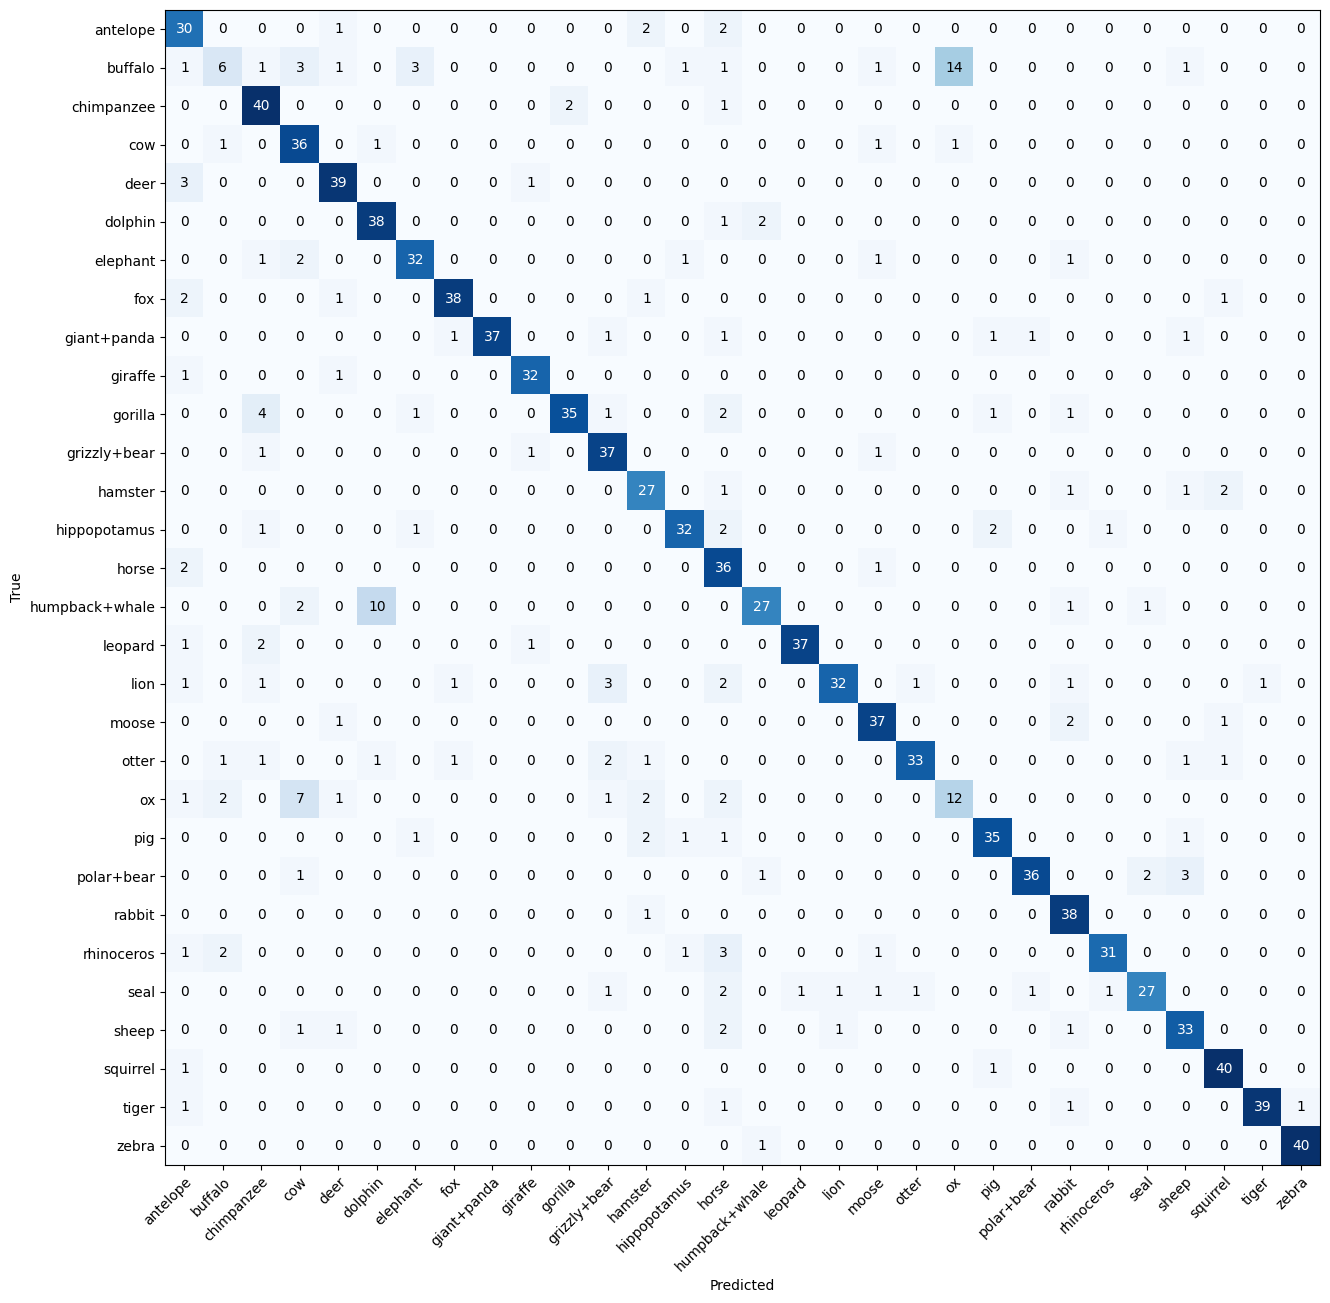

In [ ]:
#create a tensor with all predictions
preds = []
test_acc = 0
for image, label  in tqdm(test_data):
    image, label = image.to(user_device), torch.tensor(label).to(user_device)
    loaded_mobilenet3.eval()
    with torch.inference_mode():
        logits = loaded_mobilenet3(image.unsqueeze(dim=0))
        pred = logits.argmax(dim=1)
        preds.append(pred)

preds_tensor = torch.tensor(preds, dtype=torch.long)
label_tensor = torch.tensor(test_data.targets, dtype=torch.long)
test_acc = acc_fn(preds_tensor, label_tensor) 
print(f"Test Accuracy: {test_acc*100}%")

#create confusion matrix
confusion_matrix_fn = torchmetrics.ConfusionMatrix(task="multiclass", num_classes=len(test_data.classes))
confusion_matrix_tensor = confusion_matrix_fn(preds_tensor, label_tensor)

#print confusion matrix
from mlxtend.plotting import plot_confusion_matrix
fig, ax = plot_confusion_matrix(conf_mat=confusion_matrix_tensor.numpy(), class_names=test_data.classes, figsize=(12,12))

## Analizing matrix 
* model confuses sometimes whale and dolphin
* model confuses ox and buffalo